# 13: Time-Series Causal Discovery

Time-series causal discovery asks a different question from ordinary tabular discovery. In tabular data, rows are usually treated as exchangeable samples from the same joint distribution. In time-series data, row order is part of the data-generating process. A variable at time `t-1` may cause another variable at time `t`, and the direction of time gives us real background knowledge that is not available in a purely cross-sectional dataset.

We introduce the time-series workflow available in `causal-learn` and related LiNGAM time-series tools shipped with the same package family. We will simulate a small dynamic system with known lagged and contemporaneous causes, then compare several ways to discover the structure:

- pairwise Granger testing for two variables;
- multivariate Granger-Lasso for several variables and lags;
- VAR-LiNGAM for lagged effects plus same-time non-Gaussian effects;
- a deliberately naive i.i.d. PC run to show what can go wrong when temporal dependence is ignored.

The examples are small by design. A serious time-series causal discovery project should also study stationarity, seasonality, missing time points, irregular sampling, delayed effects, interventions, and domain constraints. For large lagged conditional-independence workflows, a dedicated time-series discovery library such as Tigramite is often the better primary tool. We focus on what `causal-learn` can teach directly.

Estimated runtime: about 1-3 minutes on a typical laptop. The repeated stability cells are the slowest part because they refit Granger-Lasso several times.


## Learning Goals

By the end, you should be able to:

- explain the difference between contemporaneous, lagged, and auto-regressive edges;
- reshape a multivariate time series into a lagged supervised-learning table;
- run `causal-learn`'s Granger tools and read the coefficient layout correctly;
- run VAR-LiNGAM and separate instantaneous effects from lagged effects;
- evaluate discovered lagged edges against a known synthetic truth;
- understand why ordinary i.i.d. graph discovery is risky on autocorrelated rows.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Time-Series Causal Discovery**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment uses temporal ordering and lag structure. Time order helps, but autocorrelation and contemporaneous dependence still need careful interpretation.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Time-series discovery separates contemporaneous association from lagged structure. A simple lagged model is

$$
X_t=\sum_{\ell=1}^{L}A_{\ell}X_{t-\ell}+\varepsilon_t.
$$

A directed lagged edge from variable $j$ to variable $i$ at lag $\ell$ corresponds to

$$
(A_{\ell})_{ij}\neq 0.
$$

Temporal order helps, but stationarity, lag choice, hidden drivers, and contemporaneous effects still matter.



We will move in the same order a real analysis should move:

1. Set up imports, output paths, and plotting style.
2. Define the true dynamic data-generating process.
3. Simulate and inspect a multivariate time series.
4. Draw the true temporal graph so the estimators have a clear target.
5. Build lagged design matrices to make the time-series framing concrete.
6. Run pairwise Granger and multivariate Granger-Lasso.
7. Run VAR-LiNGAM to recover same-time and lagged effects.
8. Compare results, tune thresholds, and run simple stability checks.
9. Show why naive i.i.d. PC can be misleading for time series.
10. Save a compact reporting checklist.





## Tutorial Workflow

### Time-Series Causal Discovery Theory

A time-series causal graph usually has nodes like `X(t)`, `X(t-1)`, and `X(t-2)` rather than only `X`. That indexing changes the meaning of an edge.

A **lagged edge** such as `match(t-1) -> engagement(t)` says earlier match quality helps predict later engagement after accounting for other lagged variables. Lagged edges are often easier to orient because causes must come before effects in time.

A **same-time edge** such as `match(t) -> engagement(t)` says there is an instantaneous structural relation inside the same time step. Same-time edges are harder because the timestamp alone does not order the two variables. VAR-LiNGAM uses non-Gaussian residual structure to estimate these same-time directions.

An **auto-regressive edge** such as `engagement(t-1) -> engagement(t)` says the process has memory. Auto-regression is not a nuisance detail. If we ignore it, ordinary tabular methods may mistake persistence for causal dependence between variables.


### Granger Causality in Plain Language

Granger causality is predictive causality over time. Variable `X` Granger-causes variable `Y` if past values of `X` improve prediction of current `Y`, after using past values of `Y` and possibly other variables.

That is useful because it gives time ordering a formal role in the graph search. Granger causality can be distorted by hidden common causes, omitted variables, synchronized measurement, nonstationarity, and insufficient lag length. In this lesson we use Granger methods as discovery tools, then evaluate them against a known synthetic truth.


### VAR-LiNGAM in Plain Language

VAR-LiNGAM combines two ideas:

- a vector autoregression, which models how lagged variables affect current variables;
- LiNGAM, which uses linear non-Gaussian residuals to orient same-time causal effects.

The fitted object returns an array of adjacency matrices. Matrix `0` is the same-time matrix. Matrix `1` is lag one, matrix `2` is lag two, and so on. As in the other LiNGAM lessons, the convention is row = target and column = source.


### Assumptions and Caveats

The cleanest version of the workflow assumes evenly spaced observations, no missing timestamps, approximate stationarity, enough data for the selected lag length, and no important omitted time-varying confounders. It also assumes the effect is captured reasonably well by linear lagged relationships when using Granger-Lasso or VAR-LiNGAM.

When those assumptions are not plausible, do not treat the learned graph as a final causal answer. Treat it as a candidate structure that needs sensitivity checks, domain review, and ideally experimental or quasi-experimental support.


#### Setup

This first code block imports the packages used throughout the lesson, creates output folders, and pins plotting defaults. The `MPLCONFIGDIR` line avoids noisy matplotlib cache warnings in restricted execution environments.


In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "causal_learn":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "causal_learn" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*verbose.*deprecated.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from causallearn.search.Granger.Granger import Granger
from causallearn.search.FCMBased.lingam.var_lingam import VARLiNGAM
from causallearn.search.ConstraintBased.PC import pc
NOTEBOOK_PREFIX = "13"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")


Project root: repository root
Outputs: notebooks/tutorials/causal_learn/outputs


The output confirms that the time-series example is ready. Every object in this lesson starts with `13_`, which makes it easy to separate these files from earlier tutorial outputs.


#### Package Versions

Version information is part of reproducible causal discovery. Small implementation details can matter for graph search, regularization, and numerical thresholds, so we save the versions used to execute this lesson.


In [2]:
import causallearn
import sklearn
import statsmodels
version_table = pd.DataFrame(
    [
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "statsmodels", "version": statsmodels.__version__},
        {"package": "causal-learn", "version": getattr(causallearn, "__version__", "not exposed")},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)


,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,scikit-learn,1.6.1
3,statsmodels,0.14.6
4,causal-learn,not exposed


These versions are more than bookkeeping. Time-series discovery combines statistical tests, regression solvers, and graph conventions, so saving the environment makes later debugging much easier.


#### Define the Dynamic System

We will simulate six variables with a simple product-analytics flavor:

- `need`: underlying user need or demand pressure;
- `intent`: short-term intent signal;
- `match`: quality of the content or item match;
- `engagement`: current depth of use;
- `renewal`: future value or retention pressure;
- `support`: support burden or friction signal.

The true system has self-memory, cross-lag effects, and a few same-time effects. The self-memory terms make the series autocorrelated. The cross-lag effects are the main Granger-style causal targets. The same-time effects give VAR-LiNGAM something that plain Granger-Lasso cannot fully represent.


In [3]:
VARIABLES = ["need", "intent", "match", "engagement", "renewal", "support"]
VAR_INDEX = {name: i for i, name in enumerate(VARIABLES)}
N_VARIABLES = len(VARIABLES)
SELF_LAG_STRENGTH = {
    "need": 0.35,
    "intent": 0.32,
    "match": 0.28,
    "engagement": 0.30,
    "renewal": 0.34,
    "support": 0.26,
}
CROSS_LAG_EDGES = [
    {"source": "need", "lag": 1, "target": "match", "coefficient": 0.28},
    {"source": "intent", "lag": 1, "target": "match", "coefficient": 0.34},
    {"source": "match", "lag": 1, "target": "engagement", "coefficient": 0.32},
    {"source": "engagement", "lag": 1, "target": "renewal", "coefficient": 0.36},
    {"source": "engagement", "lag": 1, "target": "support", "coefficient": -0.30},
    {"source": "support", "lag": 1, "target": "renewal", "coefficient": -0.24},
    {"source": "need", "lag": 2, "target": "engagement", "coefficient": 0.18},
    {"source": "match", "lag": 2, "target": "renewal", "coefficient": 0.22},
]
CONTEMPORANEOUS_EDGES = [
    {"source": "match", "lag": 0, "target": "engagement", "coefficient": 0.22},
    {"source": "engagement", "lag": 0, "target": "renewal", "coefficient": 0.18},
    {"source": "engagement", "lag": 0, "target": "support", "coefficient": -0.15},
]
true_edge_table = pd.DataFrame(CONTEMPORANEOUS_EDGES + CROSS_LAG_EDGES)
true_edge_table["edge_family"] = np.where(true_edge_table["lag"].eq(0), "same_time", "cross_lag")
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_temporal_edges.csv", index=False)
display(true_edge_table)


,source,lag,target,coefficient,edge_family
0,match,0,engagement,0.22,same_time
1,engagement,0,renewal,0.18,same_time
2,engagement,0,support,-0.15,same_time
3,need,1,match,0.28,cross_lag
4,intent,1,match,0.34,cross_lag
5,match,1,engagement,0.32,cross_lag
6,engagement,1,renewal,0.36,cross_lag
7,engagement,1,support,-0.30,cross_lag
8,support,1,renewal,-0.24,cross_lag
9,need,2,engagement,0.18,cross_lag


This table is the ground truth used for evaluation. Self-lag memory is real in the simulation, but the main discovery score focuses on cross-variable effects because those are the edges analysts usually mean by causal discovery across variables.


#### Simulation Function

This function creates the actual time series. It uses Laplace noise rather than Gaussian noise so VAR-LiNGAM has the non-Gaussian residual structure it needs for same-time orientation.

The code applies same-time effects in a fixed acyclic order: `match` can affect `engagement`, and `engagement` can affect `renewal` and `support` during the same timestamp.


In [4]:
def build_temporal_matrices():
    """
    Return true same-time, lag-one, and lag-two coefficient matrices.
    
    Matrix convention: row = target variable, column = source variable.
    
    Returns
    -------
    tuple
        Tuple containing same_time, lag_one, lag_two.
    """
    lag_one = np.zeros((N_VARIABLES, N_VARIABLES))
    lag_two = np.zeros((N_VARIABLES, N_VARIABLES))
    same_time = np.zeros((N_VARIABLES, N_VARIABLES))
    for variable, value in SELF_LAG_STRENGTH.items():
        lag_one[VAR_INDEX[variable], VAR_INDEX[variable]] = value
    for edge in CROSS_LAG_EDGES:
        matrix = lag_one if edge["lag"] == 1 else lag_two
        matrix[VAR_INDEX[edge["target"]], VAR_INDEX[edge["source"]]] = edge["coefficient"]
    for edge in CONTEMPORANEOUS_EDGES:
        same_time[VAR_INDEX[edge["target"]], VAR_INDEX[edge["source"]]] = edge["coefficient"]
    return same_time, lag_one, lag_two
def simulate_time_series(n_steps=1_200, burn_in=120, seed=RANDOM_SEED, noise_scale=0.60):
    """
    Simulate a stationary nonlinear-looking but linear structural time series.
    
    Parameters
    ----------
    n_steps : int
        Number of `steps` used by `simulate_time_series`.
    burn_in : object
        Initial time-series observations discarded before analysis.
    seed : int
        Random seed for reproducible simulation or resampling.
    noise_scale : object
        Noise scale used to control signal-to-noise difficulty in the simulation.
    
    Returns
    -------
    pd.DataFrame
        Simulated time-series dataset with contemporaneous variables and lag-driven causal structure.
    """
    rng = np.random.default_rng(seed)
    same_time, lag_one, lag_two = build_temporal_matrices()
    values = np.zeros((n_steps + burn_in, N_VARIABLES))
    for t in range(2, n_steps + burn_in):
        # Lagged structural component plus non-Gaussian shocks.
        base = lag_one @ values[t - 1] + lag_two @ values[t - 2]
        current = base + rng.laplace(loc=0.0, scale=noise_scale, size=N_VARIABLES)
        # Same-time effects are applied in a known acyclic order.
        current[VAR_INDEX["engagement"]] += same_time[VAR_INDEX["engagement"], VAR_INDEX["match"]] * current[VAR_INDEX["match"]]
        current[VAR_INDEX["renewal"]] += same_time[VAR_INDEX["renewal"], VAR_INDEX["engagement"]] * current[VAR_INDEX["engagement"]]
        current[VAR_INDEX["support"]] += same_time[VAR_INDEX["support"], VAR_INDEX["engagement"]] * current[VAR_INDEX["engagement"]]
        values[t] = current
    frame = pd.DataFrame(values[burn_in:], columns=VARIABLES)
    frame.insert(0, "time", np.arange(len(frame)))
    return frame
time_series_df = simulate_time_series()
time_series_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_time_series.csv", index=False)
display(time_series_df.head())


,time,need,intent,match,engagement,renewal,support
0,0,-0.285133,0.277932,2.887705,0.986429,1.117906,0.885094
1,1,0.413857,-0.507032,0.902884,0.358165,0.804738,1.329916
2,2,0.160326,-0.248611,-1.384983,1.552417,0.050189,-1.493999
3,3,-0.369289,-1.298811,-0.483863,0.010198,0.853096,-2.225829
4,4,-1.029062,-0.573211,-1.947375,-0.248455,-0.050569,-0.846873


The first rows are already past the burn-in period, so the values are sampled from the stable part of the process rather than from the all-zero initialization.





## Diagnostics and Interpretation

### Basic Data Audit

Before running discovery, inspect scale, missingness, and rough distribution shape. A time-series algorithm can fail for mundane reasons like missing timestamps, exploding values, or a variable with almost no variance.


In [5]:
data_audit = pd.DataFrame(
    {
        "mean": time_series_df[VARIABLES].mean(),
        "std": time_series_df[VARIABLES].std(),
        "min": time_series_df[VARIABLES].min(),
        "max": time_series_df[VARIABLES].max(),
        "missing_rate": time_series_df[VARIABLES].isna().mean(),
    }
).reset_index(names="variable")
time_step_check = pd.DataFrame(
    {
        "check": ["rows", "min_time", "max_time", "unique_time_steps", "missing_time_steps"],
        "value": [
            len(time_series_df),
            time_series_df["time"].min(),
            time_series_df["time"].max(),
            time_series_df["time"].nunique(),
            (time_series_df["time"].max() - time_series_df["time"].min() + 1) - time_series_df["time"].nunique(),
        ],
    }
)
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_data_audit.csv", index=False)
time_step_check.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_time_step_check.csv", index=False)
display(data_audit.round(3))
display(time_step_check)


,variable,mean,std,min,max,missing_rate
0,need,-0.014,0.925,-4.033,4.743,0.0
1,intent,-0.048,0.869,-3.818,3.915,0.0
2,match,-0.072,1.000,-4.453,4.284,0.0
3,engagement,-0.074,1.101,-4.948,6.134,0.0
4,renewal,-0.035,1.341,-5.553,4.782,0.0
5,support,0.033,1.053,-5.105,4.530,0.0


,check,value
0,rows,1200
1,min_time,0
2,max_time,1199
3,unique_time_steps,1200
4,missing_time_steps,0


The audit confirms that the simulated data has no missing values or skipped timestamps. The variables have different natural scales, so we will standardize them before regularized regression and VAR-LiNGAM.




#### Plot a Slice of the Series

A line plot serves a different role than a causal discovery method. It is still useful. We want to see whether the process looks stable and whether the variables have obvious drift or breaks that would violate stationarity assumptions.


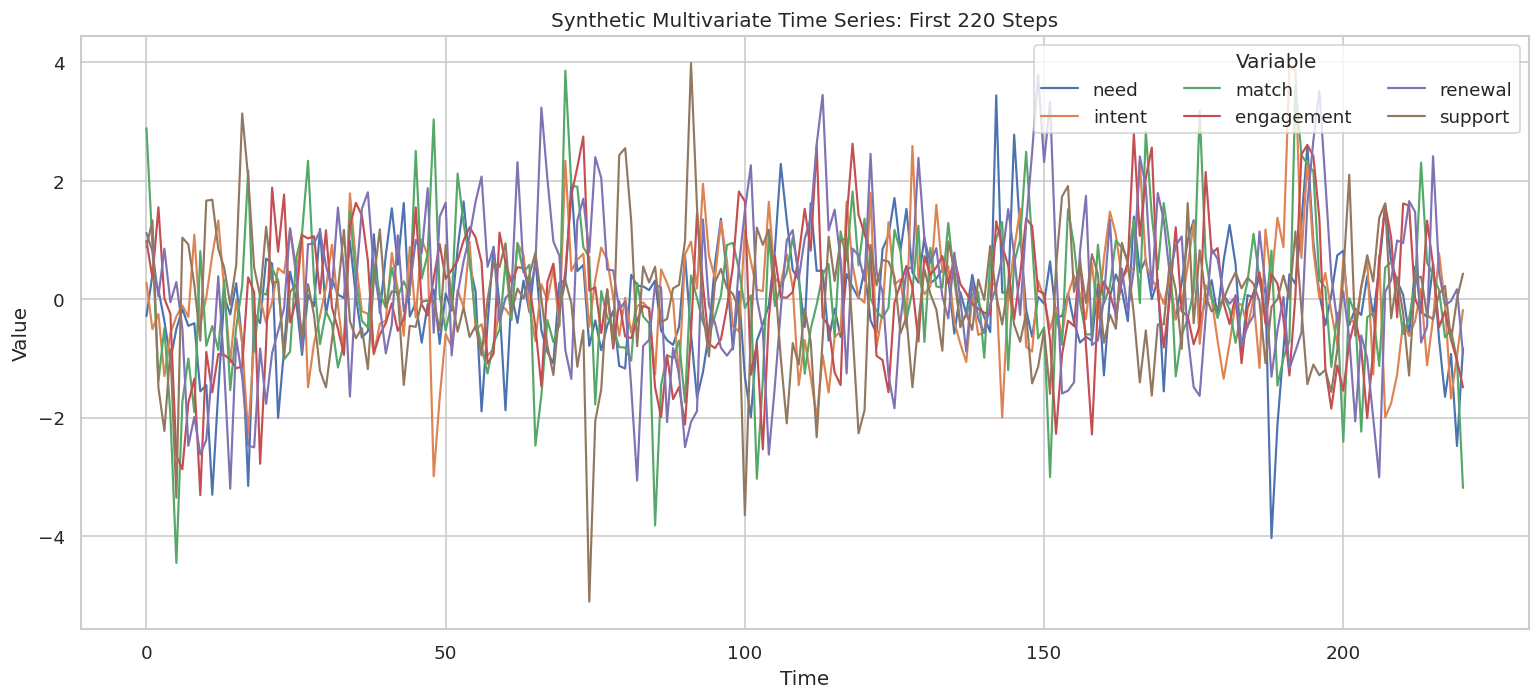

In [6]:
plot_slice = time_series_df.loc[time_series_df["time"].between(0, 220), ["time", *VARIABLES]]
plot_long = plot_slice.melt(id_vars="time", var_name="variable", value_name="value")
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=plot_long, x="time", y="value", hue="variable", linewidth=1.3, ax=ax)
ax.set_title("Synthetic Multivariate Time Series: First 220 Steps")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(title="Variable", ncols=3, loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_time_series_slice.png", dpi=160, bbox_inches="tight")
plt.show()


The series fluctuates around a stable range rather than trending away. That is the behavior we want for a first Granger and VAR-LiNGAM worked example.




### Correlation and Autocorrelation Checks

Time-series discovery should look at both cross-variable association and persistence over time. The next step saves a contemporaneous correlation matrix and simple lag-one autocorrelation values.


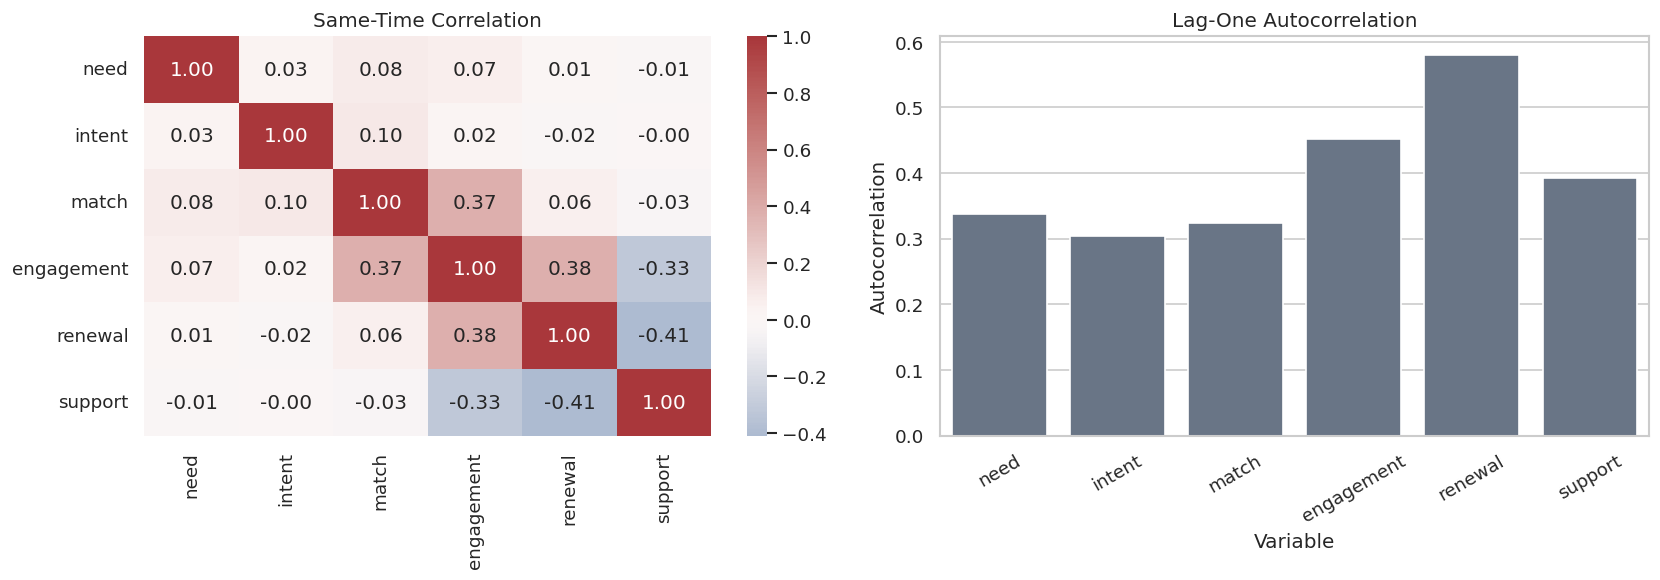

,variable,lag_1_autocorrelation,lag_2_autocorrelation
0,need,0.337,0.130
1,intent,0.304,0.098
2,match,0.323,0.106
3,engagement,0.452,0.173
4,renewal,0.580,0.314
5,support,0.393,0.142


In [7]:
correlation_matrix = time_series_df[VARIABLES].corr()
autocorrelation_table = pd.DataFrame(
    {
        "variable": VARIABLES,
        "lag_1_autocorrelation": [time_series_df[var].autocorr(lag=1) for var in VARIABLES],
        "lag_2_autocorrelation": [time_series_df[var].autocorr(lag=2) for var in VARIABLES],
    }
)
correlation_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_contemporaneous_correlation.csv")
autocorrelation_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_autocorrelation.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Same-Time Correlation")
sns.barplot(data=autocorrelation_table, x="variable", y="lag_1_autocorrelation", color="#64748b", ax=axes[1])
axes[1].set_title("Lag-One Autocorrelation")
axes[1].set_xlabel("Variable")
axes[1].set_ylabel("Autocorrelation")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_correlation_and_autocorrelation.png", dpi=160, bbox_inches="tight")
plt.show()
display(autocorrelation_table.round(3))


The autocorrelations are clearly nonzero. That is the main warning sign against treating rows as independent observations in an ordinary tabular graph discovery algorithm.




#### Draw the True Temporal Graph

This figure shows the causal target in a compact temporal layout. Arrows from `t-1` or `t-2` point into current-time variables. Arrows within the `t` column are same-time structural effects.


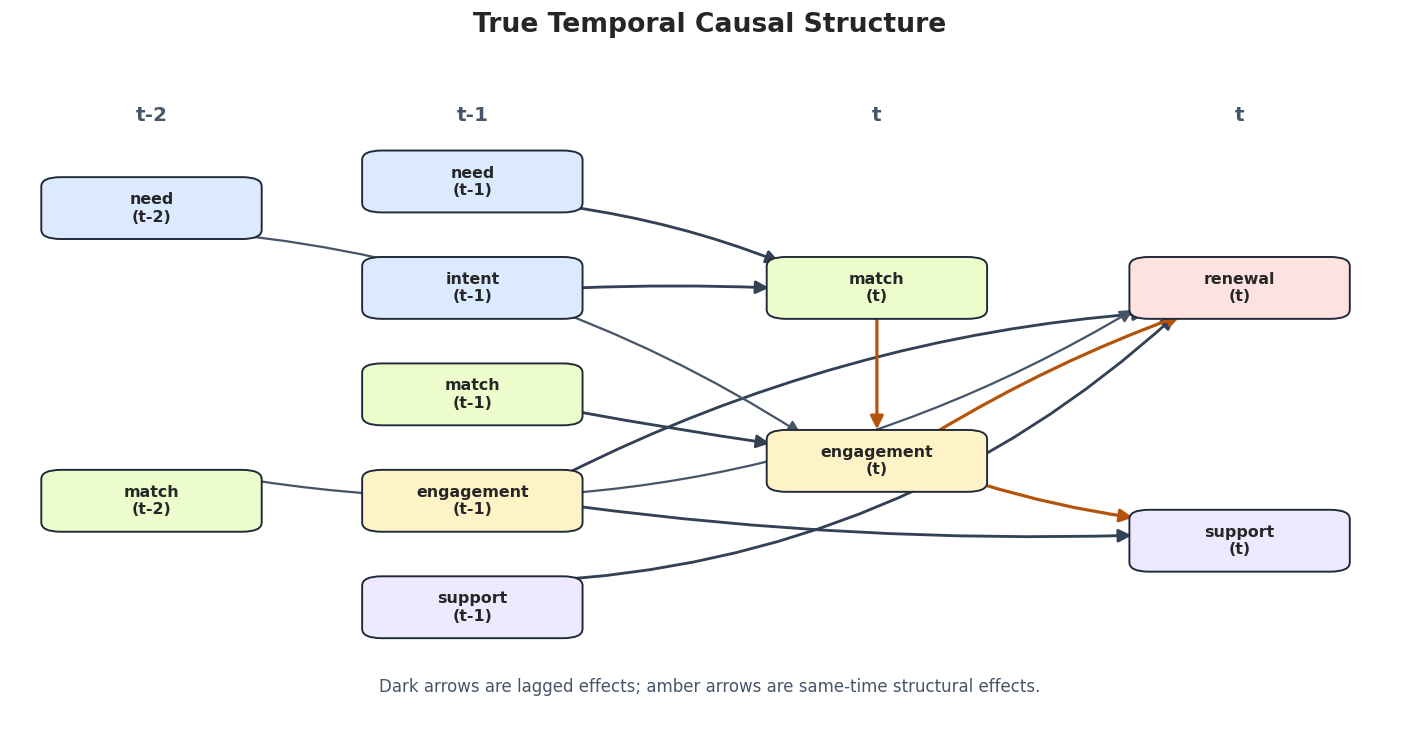

In [8]:
# Define reusable helpers for the Draw The True Temporal Graph section.
def add_box(ax, xy, label, color, width=0.13, height=0.065):
    """
    Idea: Add a labeled node box to a Matplotlib flowchart or graph diagram.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object that receives the drawing commands.
    xy : object
        Coordinate pair used to place a plotted node, label, or annotation.
    label : str
        Short label attached to a scenario, method, or plotted result.
    color : str
        Plot color used to identify this element.
    width : float
        Width used for a plotted box or simulated object.
    height : float
        Height used for a plotted box or simulated object.
    
    Returns
    -------
    None
        Adds a labeled node box directly to the supplied Matplotlib axes.
    """
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.014",
        facecolor=color,
        edgecolor="#1f2937",
        linewidth=1.15,
        zorder=4,
    )
    ax.add_patch(patch)
    ax.text(x, y, label, ha="center", va="center", fontsize=9.5, fontweight="bold", zorder=5)
def box_boundary_points(start, end, width=0.13, height=0.065, gap=0.010):
    """
    Move an arrow from node centers to rounded-box boundaries.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    width : float
        Width of the drawn box or plotted element.
    height : float
        Height of the drawn box or plotted element.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]] or float
        Adjusted boundary coordinates, or the offset used to compute them.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    distance = (dx**2 + dy**2) ** 0.5
    if distance == 0:
        return start, end
    ux, uy = dx / distance, dy / distance
    def boundary_offset(ux, uy):
        """
        Idea: Compute how far an arrow endpoint should be shifted to avoid entering a node box.
        
        Parameters
        ----------
        ux : object
            Horizontal unit direction used in arrow-boundary geometry.
        uy : object
            Vertical unit direction used in arrow-boundary geometry.
        
        Returns
        -------
        float
            Distance needed to move an arrow endpoint outside a node boundary.
        """
        candidates = []
        if abs(ux) > 1e-9:
            candidates.append((width / 2) / abs(ux))
        if abs(uy) > 1e-9:
            candidates.append((height / 2) / abs(uy))
        return min(candidates) + gap
    offset = boundary_offset(ux, uy)
    return (x0 + ux * offset, y0 + uy * offset), (x1 - ux * offset, y1 - uy * offset)
def add_arrow(ax, start, end, color="#334155", rad=0.0, lw=1.7):
    """
    Idea: Add an arrow annotation to an existing Matplotlib axes.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object that receives the drawing commands.
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    rad : float
        Curvature parameter for the plotted arrow.
    lw : float
        Line width for the plotted arrow or edge.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start_edge, end_edge = box_boundary_points(start, end)
    arrow = FancyArrowPatch(
        start_edge,
        end_edge,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=lw,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
    )
    ax.add_patch(arrow)
def draw_true_temporal_graph(path):
    """
    Idea: Draw the lagged causal structure used as the time-series benchmark.
    
    Parameters
    ----------
    path : str or pathlib.Path
        Input or output path.
    
    Returns
    -------
    None
        Draws and saves the oracle lagged temporal graph.
    """
    fig, ax = plt.subplots(figsize=(15, 7.2))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    colors = {
        "need": "#dbeafe",
        "intent": "#dbeafe",
        "match": "#ecfccb",
        "engagement": "#fef3c7",
        "renewal": "#fee2e2",
        "support": "#ede9fe",
    }
    positions = {
        ("need", 2): (0.10, 0.78),
        ("match", 2): (0.10, 0.34),
        ("need", 1): (0.33, 0.82),
        ("intent", 1): (0.33, 0.66),
        ("match", 1): (0.33, 0.50),
        ("engagement", 1): (0.33, 0.34),
        ("support", 1): (0.33, 0.18),
        ("match", 0): (0.62, 0.66),
        ("engagement", 0): (0.62, 0.40),
        ("renewal", 0): (0.88, 0.66),
        ("support", 0): (0.88, 0.28),
    }
    for x, label in [(0.10, "t-2"), (0.33, "t-1"), (0.62, "t"), (0.88, "t")]:
        ax.text(x, 0.92, label, ha="center", va="center", fontsize=12, fontweight="bold", color="#475569")
    # Draw arrows first so boxes remain crisp and readable.
    add_arrow(ax, positions[("need", 1)], positions[("match", 0)], rad=-0.06)
    add_arrow(ax, positions[("intent", 1)], positions[("match", 0)], rad=-0.02)
    add_arrow(ax, positions[("match", 1)], positions[("engagement", 0)], rad=0.01)
    add_arrow(ax, positions[("engagement", 1)], positions[("renewal", 0)], rad=-0.10)
    add_arrow(ax, positions[("engagement", 1)], positions[("support", 0)], rad=0.04)
    add_arrow(ax, positions[("support", 1)], positions[("renewal", 0)], rad=0.18)
    add_arrow(ax, positions[("need", 2)], positions[("engagement", 0)], color="#475569", rad=-0.12, lw=1.35)
    add_arrow(ax, positions[("match", 2)], positions[("renewal", 0)], color="#475569", rad=0.18, lw=1.35)
    add_arrow(ax, positions[("match", 0)], positions[("engagement", 0)], color="#b45309", rad=0.0, lw=1.9)
    add_arrow(ax, positions[("engagement", 0)], positions[("renewal", 0)], color="#b45309", rad=-0.05, lw=1.9)
    add_arrow(ax, positions[("engagement", 0)], positions[("support", 0)], color="#b45309", rad=0.04, lw=1.9)
    for (variable, lag), xy in positions.items():
        suffix = "t" if lag == 0 else f"t-{lag}"
        add_box(ax, xy, f"{variable}\n({suffix})", colors[variable])
    ax.text(
        0.50,
        0.06,
        "Dark arrows are lagged effects; amber arrows are same-time structural effects.",
        ha="center",
        va="center",
        fontsize=10,
        color="#475569",
    )
    ax.set_title("True Temporal Causal Structure", pad=18, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
draw_true_temporal_graph(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_temporal_graph.png")


The graph makes the target explicit: Granger methods should recover the dark lagged cross-variable arrows, while VAR-LiNGAM should also recover the amber same-time arrows if the linear non-Gaussian assumptions are helpful enough.


### Standardize the Series

Regularized regression and VAR fitting are easier to compare when variables are on similar scales. We standardize the six series but keep the original `time` column for plotting and alignment.


In [9]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(time_series_df[VARIABLES])
scaled_df = pd.DataFrame(scaled_values, columns=VARIABLES)
scaled_df.insert(0, "time", time_series_df["time"].to_numpy())
scaled_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_time_series_standardized.csv", index=False)
display(scaled_df.head())
display(pd.DataFrame({"variable": VARIABLES, "scaled_mean": scaled_df[VARIABLES].mean(), "scaled_std": scaled_df[VARIABLES].std()}).round(3))


,time,need,intent,match,engagement,renewal,support
0,0,-0.292979,0.374857,2.962431,0.963866,0.860149,0.809245
1,1,0.462961,-0.528326,0.975884,0.393050,0.626548,1.231873
2,2,0.188774,-0.230985,-1.313973,1.478100,0.063707,-1.451142
3,3,-0.383993,-1.439352,-0.412069,0.076901,0.662620,-2.146457
4,4,-1.097520,-0.604473,-1.876854,-0.158100,-0.011452,-0.836304


,variable,scaled_mean,scaled_std
need,need,0.0,1.0
intent,intent,0.0,1.0
match,match,-0.0,1.0
engagement,engagement,0.0,1.0
renewal,renewal,0.0,1.0
support,support,0.0,1.0


The means are approximately zero and the standard deviations are approximately one. That keeps the coefficient thresholds used later from being dominated by variable scale.


#### Build a Lagged Design Matrix

A time-series model can be rewritten as a supervised-learning table. For each current time `t`, we create columns for each variable at `t-1` and `t-2`, then keep the current variables as targets.

This is the core representation behind Granger-style models.


In [10]:
# Define reusable helpers for the Build A Lagged Design Matrix section.
def make_lagged_frame(frame, variables, max_lag=2):
    """
    Idea: Construct the lagged frame used in the Build A Lagged Design Matrix section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    variables : list[str]
        Variable names included in the graph, lag design, or diagnostic.
    max_lag : int
        Largest lag included in the time-series design matrix.
    
    Returns
    -------
    pd.DataFrame
        Lag-expanded DataFrame with current variables and their lagged predictors.
    """
    pieces = [frame[["time", *variables]].copy()]
    for lag in range(1, max_lag + 1):
        shifted = frame[variables].shift(lag).add_suffix(f"__lag_{lag}")
        pieces.append(shifted)
    lagged = pd.concat(pieces, axis=1).dropna().reset_index(drop=True)
    return lagged
lagged_df = make_lagged_frame(scaled_df, VARIABLES, max_lag=2)
lagged_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_lagged_design_matrix.csv", index=False)
display(lagged_df.head())
print(f"Lagged design shape: {lagged_df.shape}")


,time,need,intent,match,engagement,renewal,support,need__lag_1,intent__lag_1,match__lag_1,engagement__lag_1,renewal__lag_1,support__lag_1,need__lag_2,intent__lag_2,match__lag_2,engagement__lag_2,renewal__lag_2,support__lag_2
0,2,0.188774,-0.230985,-1.313973,1.478100,0.063707,-1.451142,0.462961,-0.528326,0.975884,0.393050,0.626548,1.231873,-0.292979,0.374857,2.962431,0.963866,0.860149,0.809245
1,3,-0.383993,-1.439352,-0.412069,0.076901,0.662620,-2.146457,0.188774,-0.230985,-1.313973,1.478100,0.063707,-1.451142,0.462961,-0.528326,0.975884,0.393050,0.626548,1.231873
2,4,-1.097520,-0.604473,-1.876854,-0.158100,-0.011452,-0.836304,-0.383993,-1.439352,-0.412069,0.076901,0.662620,-2.146457,0.188774,-0.230985,-1.313973,1.478100,0.063707,-1.451142
3,5,-0.528527,-0.281948,-4.384371,-2.331919,0.242976,-3.216966,-1.097520,-0.604473,-1.876854,-0.158100,-0.011452,-0.836304,-0.383993,-1.439352,-0.412069,0.076901,0.662620,-2.146457
4,6,-0.164297,-0.067427,-1.660169,-2.541614,-0.345630,0.956063,-0.528527,-0.281948,-4.384371,-2.331919,0.242976,-3.216966,-1.097520,-0.604473,-1.876854,-0.158100,-0.011452,-0.836304


Lagged design shape: (1198, 19)


The first usable row starts at time `2` because lag-two features require two previous observations. In real work, this lag construction is where you make choices about maximum lag, seasonal lags, calendar effects, and leakage prevention.




#### Helper Functions for Edge Tables and Metrics

The next helpers keep the rest of the lesson readable. They convert coefficient matrices into edge tables, compare learned edges to truth, and save compact metrics.

Reminder: matrices use row = target and column = source.


In [11]:
# Define reusable helpers for the Helper Functions For Edge Tables And Metrics section.
def coefficient_array_to_edges(coef_array, threshold, method, include_self=False):
    """
    Convert a same-time/lagged coefficient array into a tidy edge table.
    
    Parameters
    ----------
    coef_array : object
        Coefficient array produced by a time-series or linear model.
    threshold : object
        Cutoff used to retain coefficients, edges, or decisions.
    method : str
        Method name passed to the estimator, test, or graph algorithm.
    include_self : object
        Whether self-lag relationships are included in the temporal edge table.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for coefficient array to edges, including node names and edge-orientation information where available.
    """
    rows = []
    for lag, matrix in enumerate(coef_array):
        for target in VARIABLES:
            for source in VARIABLES:
                if not include_self and source == target:
                    continue
                coefficient = float(matrix[VAR_INDEX[target], VAR_INDEX[source]])
                if abs(coefficient) >= threshold:
                    rows.append(
                        {
                            "method": method,
                            "source": source,
                            "lag": lag,
                            "target": target,
                            "coefficient": coefficient,
                            "abs_coefficient": abs(coefficient),
                            "edge_label": f"{source}(t-{lag}) -> {target}(t)" if lag else f"{source}(t) -> {target}(t)",
                        }
                    )
    return pd.DataFrame(rows).sort_values(["lag", "target", "source"]).reset_index(drop=True) if rows else pd.DataFrame(columns=["method", "source", "lag", "target", "coefficient", "abs_coefficient", "edge_label"])
def granger_coefficients_to_array(coef_matrix, max_lag):
    """
    Change causal-learn Granger output from (target, source-by-lag) to (lag, target, source).
    
    Parameters
    ----------
    coef_matrix : np.ndarray
        Matrix representation of `coef`.
    max_lag : object
        Largest time lag included in the temporal design matrix.
    
    Returns
    -------
    np.ndarray
        Coefficient array arranged by same-time and lagged effects for temporal edge inspection.
    """
    lagged_matrices = []
    for lag in range(1, max_lag + 1):
        start = (lag - 1) * N_VARIABLES
        stop = lag * N_VARIABLES
        lagged_matrices.append(coef_matrix[:, start:stop])
    zero_same_time = np.zeros((N_VARIABLES, N_VARIABLES))
    return np.array([zero_same_time, *lagged_matrices])
def edge_key_set(edge_table, allowed_lags=None, exclude_self=True):
    """
    Idea: Build comparable edge keys from an edge table, with optional lag filtering for temporal graphs.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Directed or partially directed edges to summarize.
    allowed_lags : collection[int]
        Lag values eligible when evaluating temporal edges.
    exclude_self : object
        Whether self-lag edges are excluded from the temporal edge set.
    
    Returns
    -------
    set[tuple]
        Comparable edge keys, optionally including temporal lag values.
    """
    if edge_table.empty:
        return set()
    subset = edge_table.copy()
    if allowed_lags is not None:
        subset = subset[subset["lag"].isin(allowed_lags)]
    if exclude_self:
        subset = subset[subset["source"] != subset["target"]]
    return set(zip(subset["source"], subset["lag"], subset["target"]))
TRUE_EDGE_KEYS = edge_key_set(true_edge_table, allowed_lags=[0, 1, 2], exclude_self=True)
TRUE_LAGGED_EDGE_KEYS = edge_key_set(true_edge_table, allowed_lags=[1, 2], exclude_self=True)
TRUE_SAME_TIME_EDGE_KEYS = edge_key_set(true_edge_table, allowed_lags=[0], exclude_self=True)
def summarize_edges(predicted_edges, truth_keys, label):
    """
    Idea: Summarize the edges into a compact table for interpretation in the Helper Functions For Edge Tables And Metrics section.
    
    Parameters
    ----------
    predicted_edges : pd.DataFrame or set
        Edges recovered by the algorithm being evaluated.
    truth_keys : set
        Known true graph edges used as the benchmark.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for summarize edges, including node names and edge-orientation information where available.
    """
    predicted_keys = edge_key_set(predicted_edges, allowed_lags=[0, 1, 2], exclude_self=True)
    true_positive = predicted_keys & truth_keys
    false_positive = predicted_keys - truth_keys
    false_negative = truth_keys - predicted_keys
    precision = len(true_positive) / len(predicted_keys) if predicted_keys else np.nan
    recall = len(true_positive) / len(truth_keys) if truth_keys else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else np.nan
    return pd.DataFrame(
        [
            {
                "method": label,
                "predicted_edges": len(predicted_keys),
                "true_edges": len(truth_keys),
                "true_positive_edges": len(true_positive),
                "false_positive_edges": len(false_positive),
                "false_negative_edges": len(false_negative),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "missed_edges": " | ".join(f"{s}(t-{l}) -> {t}(t)" if l else f"{s}(t) -> {t}(t)" for s, l, t in sorted(false_negative)),
                "extra_edges": " | ".join(f"{s}(t-{l}) -> {t}(t)" if l else f"{s}(t) -> {t}(t)" for s, l, t in sorted(false_positive)),
            }
        ]
    )
def save_metrics(metrics, name):
    """
    Idea: Save the metric table for the current benchmark scenario and return it for inspection.
    
    Parameters
    ----------
    metrics : object
        Metric table or metric dictionary being saved or displayed.
    name : str
        Short name used for the scenario label.
    
    Returns
    -------
    pd.DataFrame or dict
        Benchmark metrics after saving them to the tutorial output folder.
    """
    metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv", index=False)
    display(metrics.round(4))


The metric helpers deliberately evaluate exact lag labels. For example, `match(t-1) -> engagement(t)` is different from `match(t-2) -> engagement(t)`. In time-series discovery, lag placement is part of the causal claim.




#### Pairwise Granger Test

We start with the simplest causal-learn time-series tool: a two-variable Granger test. This asks whether past `match` predicts current `engagement`, and whether past `engagement` predicts current `match`.

This is only pairwise. It uses a partial view of the multivariate system, so it is useful as a teaching step before the final graph.


In [12]:
pair_variables = ["match", "engagement"]
pair_data = scaled_df[pair_variables].to_numpy()
pair_model = Granger(maxlag=2, significance_level=0.01)
pair_p_values, pair_adjacency = pair_model.granger_test_2d(pair_data)
pair_rows = []
for target_index, target in enumerate(pair_variables):
    for source_index, source in enumerate(pair_variables):
        if source == target:
            continue
        for lag in [1, 2]:
            p_value = pair_p_values[target_index, source_index + len(pair_variables) * (lag - 1)]
            pair_rows.append(
                {
                    "source": source,
                    "lag": lag,
                    "target": target,
                    "p_value": p_value,
                    "significant_at_1pct": p_value < 0.01,
                }
            )
pairwise_granger_table = pd.DataFrame(pair_rows)
pairwise_granger_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_granger_match_engagement.csv", index=False)
display(pairwise_granger_table)


,source,lag,target,p_value,significant_at_1pct
0,engagement,1,match,0.7020,False
1,engagement,2,match,0.5321,False
2,match,1,engagement,0.0000,True
3,match,2,engagement,0.0000,True


The pairwise test correctly finds strong evidence from past `match` to current `engagement`. The reverse direction is not significant here, which matches the main synthetic design for this pair.


#### Multivariate Granger-Lasso

Now we use `Granger.granger_lasso`, which fits one regularized regression per target variable using all variables at all selected lags as predictors. This is closer to a discovery workflow because each candidate edge competes against the other lagged variables.

The output is a coefficient matrix with shape `(number_of_targets, number_of_variables * max_lag)`. We convert it into one matrix per lag so the edge convention is easier to read.


In [13]:
MAX_LAG = 2
GRANGER_THRESHOLD = 0.08
granger_model = Granger(maxlag=MAX_LAG, cv=5)
start_time = time.perf_counter()
granger_raw_coefficients = granger_model.granger_lasso(scaled_df[VARIABLES].to_numpy())
granger_elapsed = time.perf_counter() - start_time
granger_coef_array = granger_coefficients_to_array(granger_raw_coefficients, max_lag=MAX_LAG)
granger_edges = coefficient_array_to_edges(
    granger_coef_array,
    threshold=GRANGER_THRESHOLD,
    method="Granger_Lasso",
    include_self=False,
)
granger_metrics = summarize_edges(granger_edges, TRUE_LAGGED_EDGE_KEYS, "Granger_Lasso_lagged_edges")
granger_metrics["threshold"] = GRANGER_THRESHOLD
granger_metrics["elapsed_seconds"] = granger_elapsed
granger_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_granger_lasso_edges.csv", index=False)
save_metrics(granger_metrics, "granger_lasso_metrics")
display(granger_edges.round(4))


,method,predicted_edges,true_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1,missed_edges,extra_edges,threshold,elapsed_seconds
0,Granger_Lasso_lagged_edges,8,8,8,0,0,1.0,1.0,1.0,,,0.08,0.2048


,method,source,lag,target,coefficient,abs_coefficient,edge_label
0,Granger_Lasso,match,1,engagement,0.3515,0.3515,match(t-1) -> engagement(t)
1,Granger_Lasso,intent,1,match,0.2891,0.2891,intent(t-1) -> match(t)
2,Granger_Lasso,need,1,match,0.2528,0.2528,need(t-1) -> match(t)
3,Granger_Lasso,engagement,1,renewal,0.3489,0.3489,engagement(t-1) -> renewal(t)
4,Granger_Lasso,support,1,renewal,-0.1748,0.1748,support(t-1) -> renewal(t)
5,Granger_Lasso,engagement,1,support,-0.3702,0.3702,engagement(t-1) -> support(t)
6,Granger_Lasso,need,2,engagement,0.1192,0.1192,need(t-2) -> engagement(t)
7,Granger_Lasso,match,2,renewal,0.1280,0.1280,match(t-2) -> renewal(t)


At this threshold, Granger-Lasso recovers the intended cross-lag structure cleanly. The coefficient signs also line up with the data-generating process: support burden has a negative effect on renewal, and engagement has a negative effect on later support burden in this synthetic design.


#### Visualize Granger-Lasso Lag Matrices

A matrix view is often easier than a long edge table. The next figure shows the estimated lag-one and lag-two coefficients. Rows are targets and columns are sources.


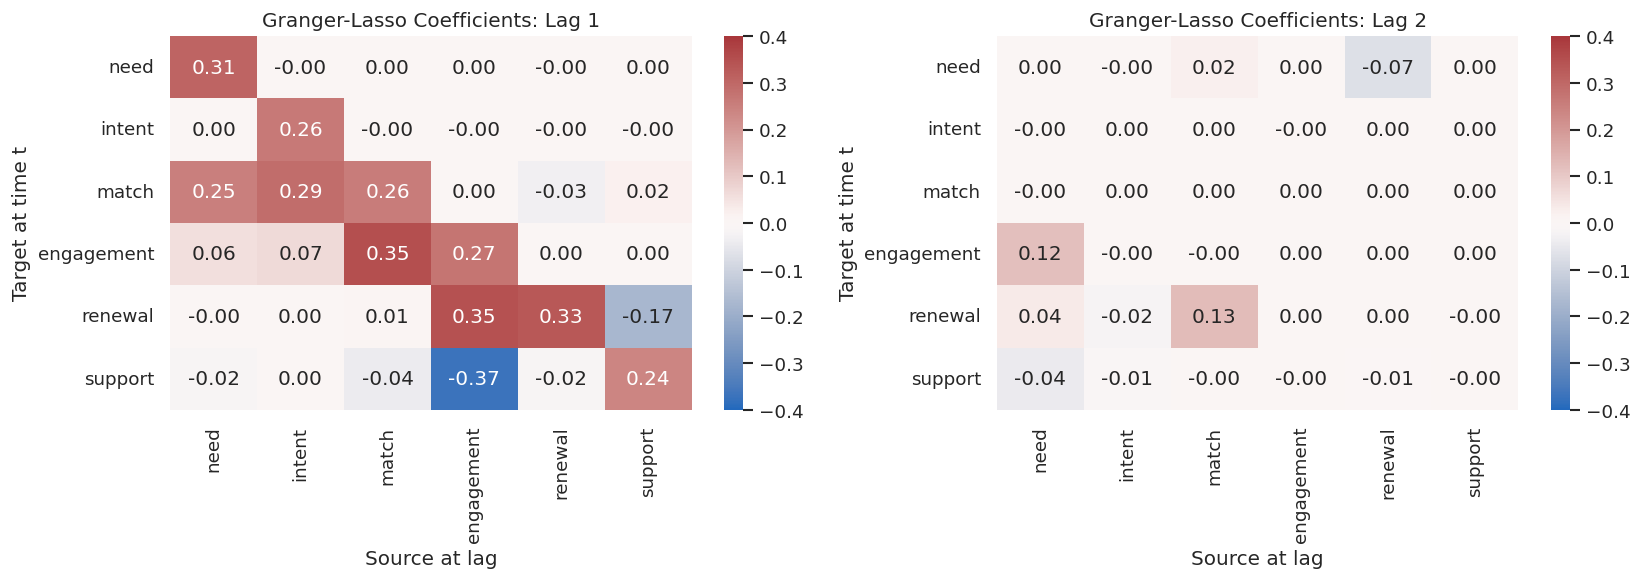

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for plot_index, lag in enumerate([1, 2]):
    matrix = granger_coef_array[lag]
    sns.heatmap(
        pd.DataFrame(matrix, index=VARIABLES, columns=VARIABLES),
        cmap="vlag",
        center=0,
        vmin=-0.40,
        vmax=0.40,
        annot=True,
        fmt=".2f",
        ax=axes[plot_index],
    )
    axes[plot_index].set_title(f"Granger-Lasso Coefficients: Lag {lag}")
    axes[plot_index].set_xlabel("Source at lag")
    axes[plot_index].set_ylabel("Target at time t")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_granger_lasso_lag_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()


The strongest off-diagonal cells correspond to the true lagged edges. The diagonal cells show self-memory, which is expected in a time series and should usually be reported separately from cross-variable causal edges.




#### Threshold Sensitivity for Granger-Lasso

Regularized coefficients need a practical threshold before they become a graph. Instead of choosing one threshold silently, we scan several values and report precision and recall against the synthetic truth.


In [15]:
threshold_rows = []
for threshold in [0.04, 0.06, 0.08, 0.10, 0.12]:
    candidate_edges = coefficient_array_to_edges(
        granger_coef_array,
        threshold=threshold,
        method="Granger_Lasso",
        include_self=False,
    )
    candidate_metrics = summarize_edges(candidate_edges, TRUE_LAGGED_EDGE_KEYS, f"threshold_{threshold:.2f}")
    candidate_metrics["threshold"] = threshold
    threshold_rows.append(candidate_metrics)
granger_threshold_metrics = pd.concat(threshold_rows, ignore_index=True)
granger_threshold_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_granger_threshold_sensitivity.csv", index=False)
display(granger_threshold_metrics[["threshold", "predicted_edges", "true_positive_edges", "false_positive_edges", "false_negative_edges", "precision", "recall", "f1"]].round(4))


,threshold,predicted_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1
0,0.04,13,8,5,0,0.6154,1.000,0.7619
1,0.06,10,8,2,0,0.8000,1.000,0.8889
2,0.08,8,8,0,0,1.0000,1.000,1.0000
3,0.10,8,8,0,0,1.0000,1.000,1.0000
4,0.12,7,7,0,1,1.0000,0.875,0.9333


The sensitivity table shows why the chosen threshold is reasonable for this example dataset. Lower thresholds admit extra weak edges; higher thresholds can eventually drop weaker true lag-two effects.


#### Plot Threshold Sensitivity

The next plot turns the threshold table into a quick diagnostic. A good threshold region should not be a single fragile point.


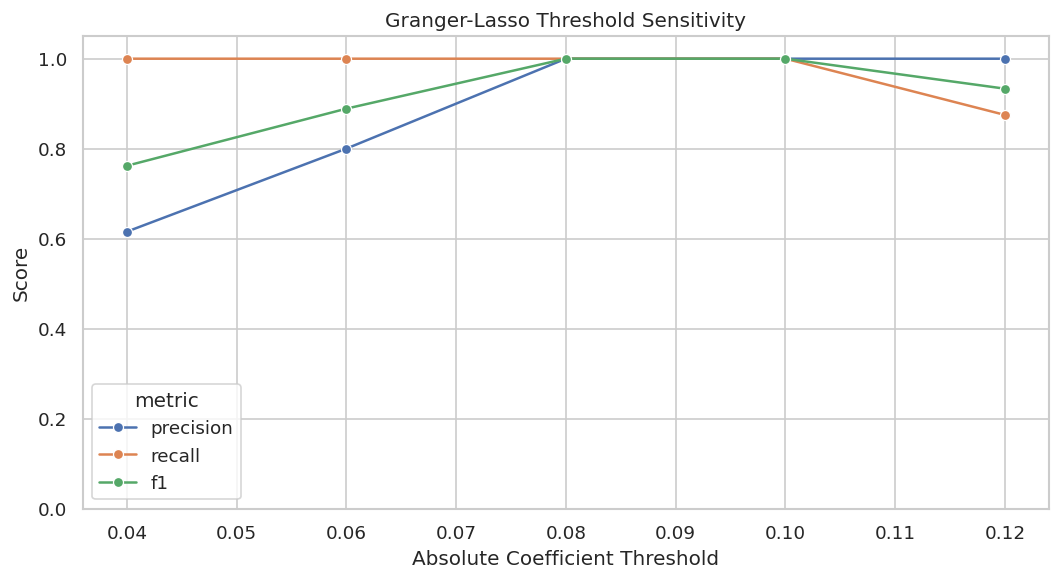

In [16]:
plot_thresholds = granger_threshold_metrics.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=plot_thresholds, x="threshold", y="score", hue="metric", marker="o", ax=ax)
ax.set_title("Granger-Lasso Threshold Sensitivity")
ax.set_xlabel("Absolute Coefficient Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_granger_threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the threshold tradeoff visible: the useful region is where recall remains high without admitting many false positive edges.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




### VAR-LiNGAM

Granger-Lasso is designed for lagged predictive effects. VAR-LiNGAM adds a same-time LiNGAM step on the residuals, so it can estimate both instantaneous and lagged coefficients under linear non-Gaussian assumptions.

We fit two lags because that matches the synthetic data-generating process.


In [17]:
VARLINGAM_THRESHOLD = 0.07
var_lingam_model = VARLiNGAM(lags=MAX_LAG, criterion=None, prune=False, random_state=RANDOM_SEED)
start_time = time.perf_counter()
var_lingam_model.fit(scaled_df[VARIABLES].to_numpy())
var_lingam_elapsed = time.perf_counter() - start_time
var_lingam_coef_array = np.asarray(var_lingam_model.adjacency_matrices_)
var_lingam_edges = coefficient_array_to_edges(
    var_lingam_coef_array,
    threshold=VARLINGAM_THRESHOLD,
    method="VAR_LiNGAM",
    include_self=False,
)
var_lingam_metrics = summarize_edges(var_lingam_edges, TRUE_EDGE_KEYS, "VAR_LiNGAM_same_time_and_lagged")
var_lingam_metrics["threshold"] = VARLINGAM_THRESHOLD
var_lingam_metrics["elapsed_seconds"] = var_lingam_elapsed
var_lingam_metrics["estimated_causal_order"] = " -> ".join(VARIABLES[i] for i in var_lingam_model.causal_order_)
var_lingam_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_var_lingam_edges.csv", index=False)
save_metrics(var_lingam_metrics, "var_lingam_metrics")
display(var_lingam_edges.round(4))


,method,predicted_edges,true_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1,missed_edges,extra_edges,threshold,elapsed_seconds,estimated_causal_order
0,VAR_LiNGAM_same_time_and_lagged,13,11,11,2,0,0.8462,1.0,0.9167,,renewal(t-1) -> match(t) | renewal(t-2) -> need(t),0.07,0.0326,intent -> match -> engagement -> need -> renewal -> support


,method,source,lag,target,coefficient,abs_coefficient,edge_label
0,VAR_LiNGAM,match,0,engagement,0.2112,0.2112,match(t) -> engagement(t)
1,VAR_LiNGAM,engagement,0,renewal,0.1579,0.1579,engagement(t) -> renewal(t)
2,VAR_LiNGAM,engagement,0,support,-0.0910,0.0910,engagement(t) -> support(t)
3,VAR_LiNGAM,match,1,engagement,0.3133,0.3133,match(t-1) -> engagement(t)
4,VAR_LiNGAM,intent,1,match,0.3063,0.3063,intent(t-1) -> match(t)
5,VAR_LiNGAM,need,1,match,0.2721,0.2721,need(t-1) -> match(t)
6,VAR_LiNGAM,renewal,1,match,-0.0753,0.0753,renewal(t-1) -> match(t)
7,VAR_LiNGAM,engagement,1,renewal,0.3051,0.3051,engagement(t-1) -> renewal(t)
8,VAR_LiNGAM,support,1,renewal,-0.1862,0.1862,support(t-1) -> renewal(t)
9,VAR_LiNGAM,engagement,1,support,-0.3545,0.3545,engagement(t-1) -> support(t)


VAR-LiNGAM recovers both lagged effects and same-time effects in this controlled setting. The estimated causal order is specifically the same-time LiNGAM order among residual shocks, not a full time-unrolled causal order.


#### Visualize VAR-LiNGAM Matrices

The same-time matrix is labeled lag `0`. Lag `1` and lag `2` then show delayed effects. This separation is the main conceptual advantage of VAR-LiNGAM over a plain lagged regression graph.


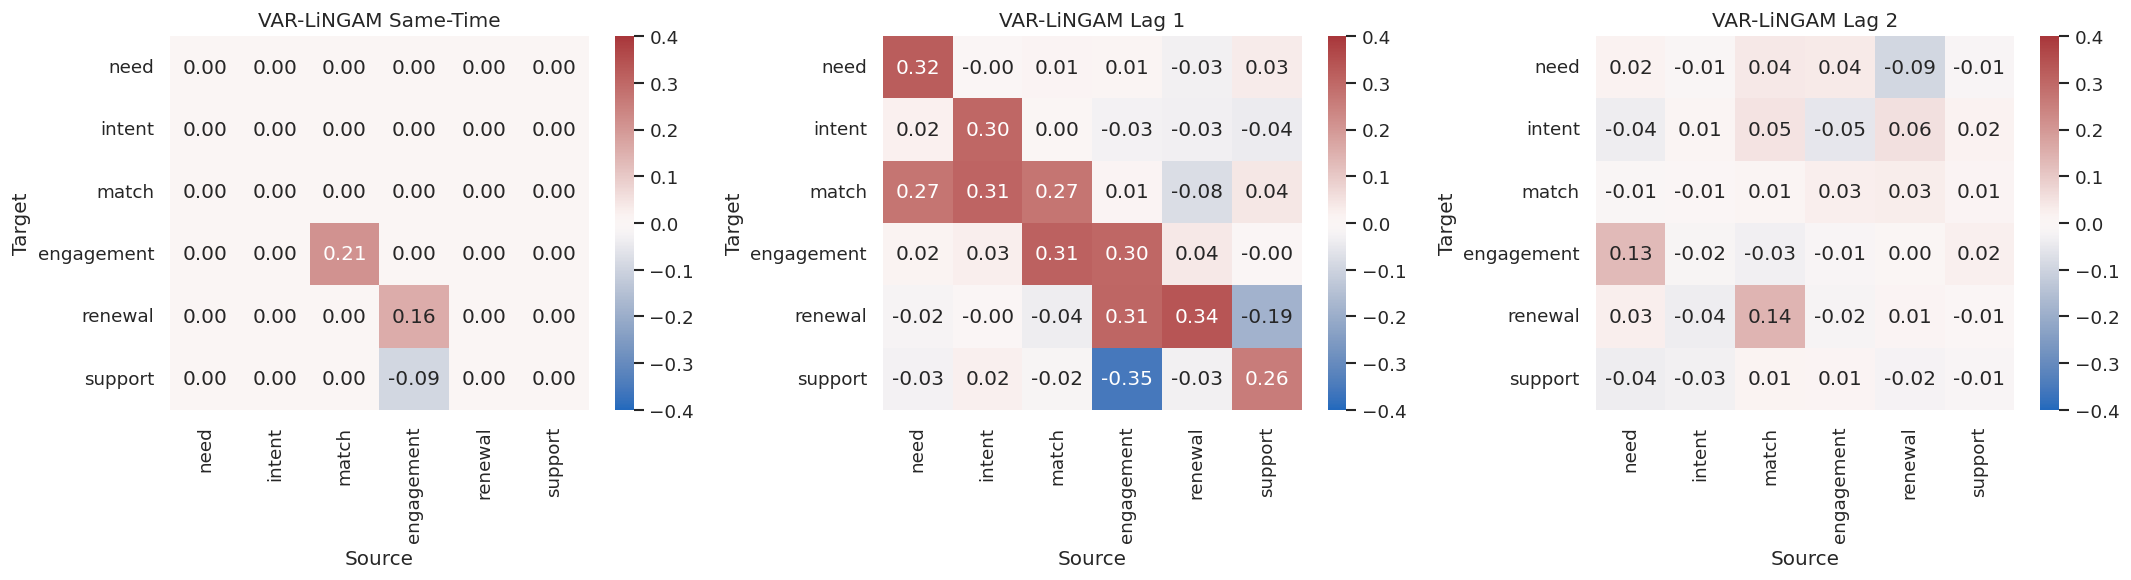

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for plot_index, lag in enumerate([0, 1, 2]):
    sns.heatmap(
        pd.DataFrame(var_lingam_coef_array[lag], index=VARIABLES, columns=VARIABLES),
        cmap="vlag",
        center=0,
        vmin=-0.40,
        vmax=0.40,
        annot=True,
        fmt=".2f",
        ax=axes[plot_index],
    )
    axes[plot_index].set_title("VAR-LiNGAM Same-Time" if lag == 0 else f"VAR-LiNGAM Lag {lag}")
    axes[plot_index].set_xlabel("Source")
    axes[plot_index].set_ylabel("Target")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_var_lingam_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmaps show why matrix indexing matters. The same-time effects appear in the first matrix, while the Granger-style delayed effects appear in the later matrices.




### Compare Granger-Lasso and VAR-LiNGAM

The two methods answer overlapping but not identical questions. Granger-Lasso is focused on lagged predictive effects. VAR-LiNGAM estimates a richer structural VAR that includes same-time effects.


In [19]:
method_comparison_metrics = pd.concat(
    [
        granger_metrics.assign(target_edge_set="lagged_only"),
        var_lingam_metrics.assign(target_edge_set="same_time_plus_lagged"),
    ],
    ignore_index=True,
)
method_comparison_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_metrics.csv", index=False)
display(method_comparison_metrics[["method", "target_edge_set", "predicted_edges", "true_positive_edges", "false_positive_edges", "false_negative_edges", "precision", "recall", "f1", "elapsed_seconds"]].round(4))


,method,target_edge_set,predicted_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1,elapsed_seconds
0,Granger_Lasso_lagged_edges,lagged_only,8,8,0,0,1.0000,1.0,1.0000,0.2048
1,VAR_LiNGAM_same_time_and_lagged,same_time_plus_lagged,13,11,2,0,0.8462,1.0,0.9167,0.0326


The comparison is not a winner-takes-all contest. The right estimator depends on whether the analysis needs only lagged predictive structure or also same-time structural direction.


#### Plot Method Comparison

A compact bar plot makes the difference in target edge sets visible. Because the methods are evaluated against different targets, the labels remind us what each score means.


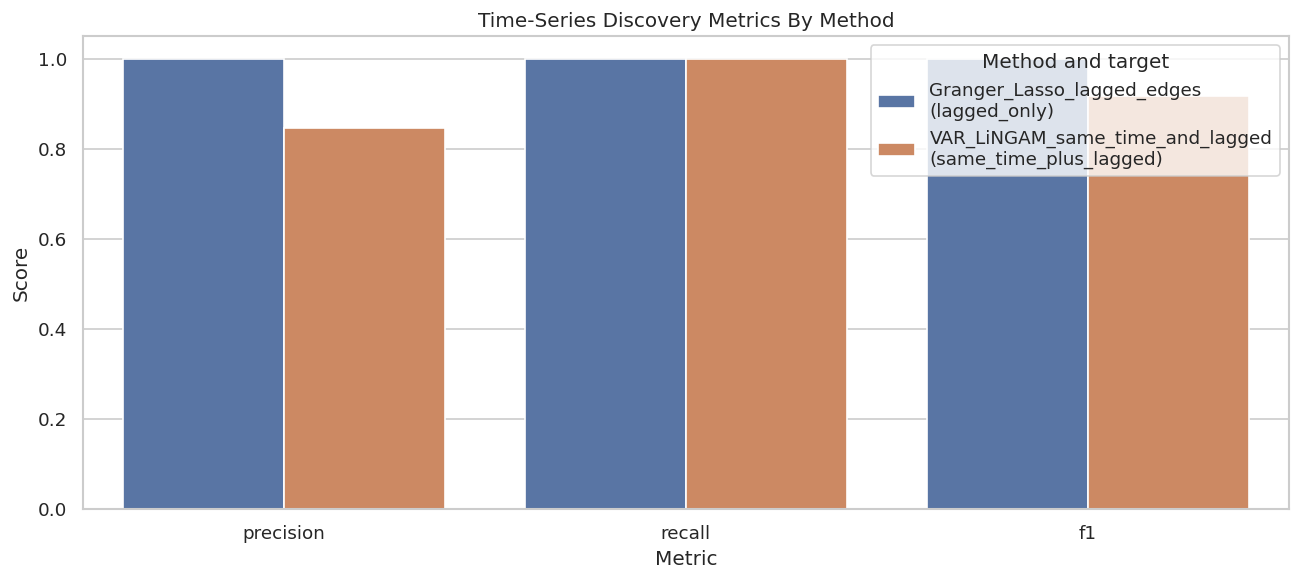

In [20]:
comparison_plot = method_comparison_metrics.melt(
    id_vars=["method", "target_edge_set"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
comparison_plot["method_label"] = comparison_plot["method"] + "\n(" + comparison_plot["target_edge_set"] + ")"
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=comparison_plot, x="metric", y="score", hue="method_label", ax=ax)
ax.set_title("Time-Series Discovery Metrics By Method")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Method and target")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


Both methods perform well because the data were generated from assumptions friendly to these estimators. In real data, this plot should be paired with stability checks and domain review rather than read as proof.


#### Seed Stability for Granger-Lasso

A single synthetic run can look cleaner than reality. The next step resimulates the system with several random seeds, refits Granger-Lasso, and checks how many true lagged cross-variable edges are recovered.


In [21]:
stability_rows = []
for seed in range(8):
    simulated = simulate_time_series(n_steps=900, burn_in=120, seed=seed)
    simulated_scaled = StandardScaler().fit_transform(simulated[VARIABLES])
    model = Granger(maxlag=MAX_LAG, cv=5)
    start_time = time.perf_counter()
    raw_coefficients = model.granger_lasso(simulated_scaled)
    elapsed = time.perf_counter() - start_time
    coef_array = granger_coefficients_to_array(raw_coefficients, max_lag=MAX_LAG)
    edges = coefficient_array_to_edges(coef_array, threshold=GRANGER_THRESHOLD, method="Granger_Lasso", include_self=False)
    metrics = summarize_edges(edges, TRUE_LAGGED_EDGE_KEYS, f"seed_{seed}")
    metrics["seed"] = seed
    metrics["elapsed_seconds"] = elapsed
    stability_rows.append(metrics)
granger_seed_stability = pd.concat(stability_rows, ignore_index=True)
granger_seed_stability.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_granger_seed_stability.csv", index=False)
display(granger_seed_stability[["seed", "predicted_edges", "true_positive_edges", "false_positive_edges", "false_negative_edges", "precision", "recall", "f1", "elapsed_seconds"]].round(4))


,seed,predicted_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1,elapsed_seconds
0,0,9,8,1,0,0.8889,1.0,0.9412,0.2054
1,1,8,8,0,0,1.0000,1.0,1.0000,0.2024
2,2,8,8,0,0,1.0000,1.0,1.0000,0.2044
3,3,9,8,1,0,0.8889,1.0,0.9412,0.2009
4,4,8,8,0,0,1.0000,1.0,1.0000,0.2016
5,5,9,8,1,0,0.8889,1.0,0.9412,0.1986
6,6,8,8,0,0,1.0000,1.0,1.0000,0.2000
7,7,9,8,1,0,0.8889,1.0,0.9412,0.1924


The seed check asks whether the result is a stable property of the data-generating process or a lucky draw. In this controlled setup the lagged graph is stable across repeated simulations.


#### Plot Seed Stability

The next plot shows precision, recall, and F1 across simulation seeds. Flat lines near one are reassuring in this synthetic setting.


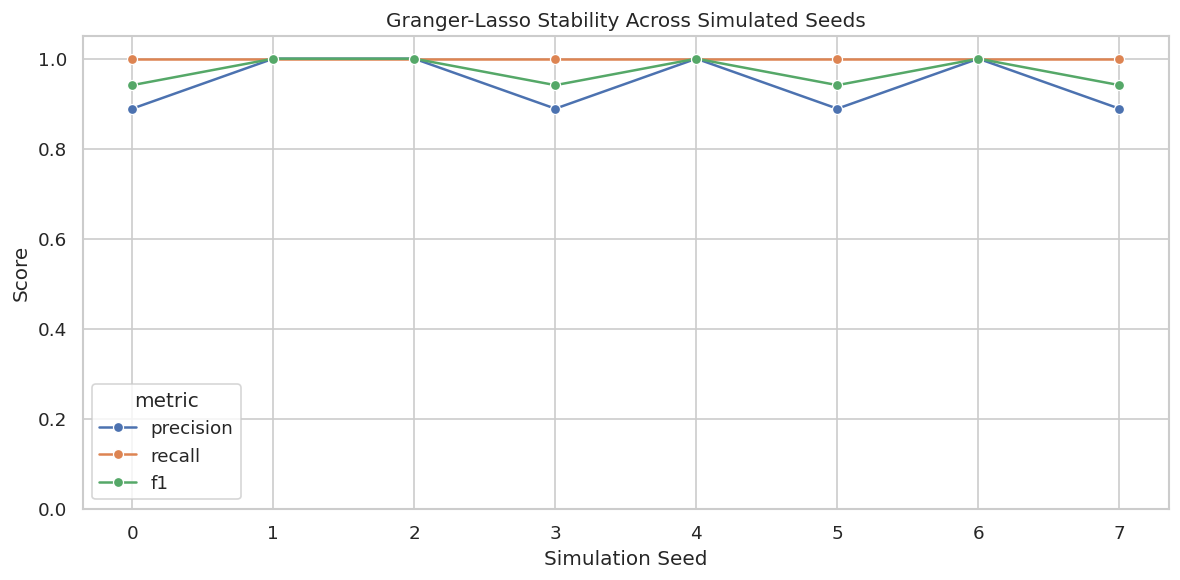

In [22]:
seed_plot = granger_seed_stability.melt(
    id_vars="seed",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=seed_plot, x="seed", y="score", hue="metric", marker="o", ax=ax)
ax.set_title("Granger-Lasso Stability Across Simulated Seeds")
ax.set_xlabel("Simulation Seed")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_granger_seed_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The plot is simple. A stable method should not require a particular random simulation to look good. On real data, an analogous check might resample blocks of time or run rolling-origin splits.


#### Sample-Size Sensitivity

Time-series discovery can be data hungry because every candidate lag multiplies the number of possible predictors. We rerun Granger-Lasso with increasing sample sizes to show how recovery changes as the available history grows.


In [23]:
sample_size_rows = []
for n_steps in [250, 400, 700, 1_200]:
    simulated = simulate_time_series(n_steps=n_steps, burn_in=120, seed=RANDOM_SEED + n_steps)
    simulated_scaled = StandardScaler().fit_transform(simulated[VARIABLES])
    model = Granger(maxlag=MAX_LAG, cv=5)
    start_time = time.perf_counter()
    raw_coefficients = model.granger_lasso(simulated_scaled)
    elapsed = time.perf_counter() - start_time
    coef_array = granger_coefficients_to_array(raw_coefficients, max_lag=MAX_LAG)
    edges = coefficient_array_to_edges(coef_array, threshold=GRANGER_THRESHOLD, method="Granger_Lasso", include_self=False)
    metrics = summarize_edges(edges, TRUE_LAGGED_EDGE_KEYS, f"n_{n_steps}")
    metrics["n_steps"] = n_steps
    metrics["elapsed_seconds"] = elapsed
    sample_size_rows.append(metrics)
granger_sample_size = pd.concat(sample_size_rows, ignore_index=True)
granger_sample_size.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_granger_sample_size_sensitivity.csv", index=False)
display(granger_sample_size[["n_steps", "predicted_edges", "true_positive_edges", "false_positive_edges", "false_negative_edges", "precision", "recall", "f1", "elapsed_seconds"]].round(4))


,n_steps,predicted_edges,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,f1,elapsed_seconds
0,250,10,7,3,1,0.7,0.875,0.7778,0.1905
1,400,8,8,0,0,1.0,1.000,1.0000,0.1965
2,700,8,8,0,0,1.0,1.000,1.0000,0.2072
3,1200,8,8,0,0,1.0,1.000,1.0000,0.2020


The smaller histories can miss weaker effects or admit extra edges. As the sample grows, the graph estimate becomes more reliable in this controlled example.


#### Plot Sample-Size Sensitivity

This plot makes the data requirement visible. A causal graph that changes dramatically with modest changes in history length should be reported cautiously.


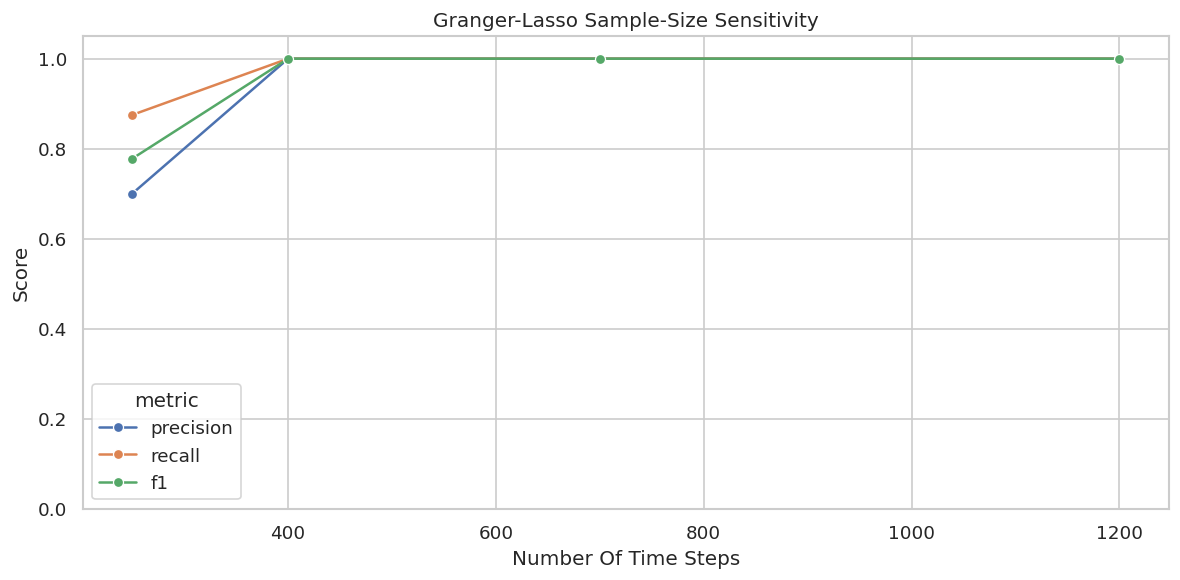

In [24]:
sample_plot = granger_sample_size.melt(
    id_vars="n_steps",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=sample_plot, x="n_steps", y="score", hue="metric", marker="o", ax=ax)
ax.set_title("Granger-Lasso Sample-Size Sensitivity")
ax.set_xlabel("Number Of Time Steps")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_granger_sample_size_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The curve gives a practical lesson: lagged discovery needs enough time points after lag construction. If a project has many variables and few time steps, the graph can be underidentified or unstable.




#### Naive I.I.D. PC as a Cautionary Example

The next step does something risky for demonstration: it runs PC directly on the same-time rows as if they were independent tabular samples. This is included to show why time-series structure should not be ignored.

The result is not treated as a valid time-series causal graph.


In [25]:
naive_pc_result = pc(
    scaled_df[VARIABLES].to_numpy(),
    alpha=0.01,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)
naive_pc_edges = pd.DataFrame({"edge": [str(edge) for edge in naive_pc_result.G.get_graph_edges()]})
naive_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_naive_iid_pc_edges.csv", index=False)
display(naive_pc_edges)


,edge
0,intent --> match
1,engagement --> match
2,engagement --- renewal
3,engagement --- support
4,renewal --- support


The naive PC graph mixes contemporaneous association, lagged persistence, and indirect effects into one same-time graph. This is the main lesson: time ordering is not optional metadata; it is part of the causal problem.


#### Runtime Sketch

Runtime grows with the number of variables, candidate lags, and repeated model fits. This quick sketch fits Granger-Lasso on variable prefixes so we can see the local scaling pattern.


In [26]:
runtime_rows = []
for n_vars in [3, 4, 5, 6]:
    selected = VARIABLES[:n_vars]
    selected_values = scaled_df[selected].to_numpy()
    model = Granger(maxlag=MAX_LAG, cv=5)
    start_time = time.perf_counter()
    model.granger_lasso(selected_values)
    elapsed = time.perf_counter() - start_time
    runtime_rows.append({"n_variables": n_vars, "max_lag": MAX_LAG, "elapsed_seconds": elapsed})
runtime_table = pd.DataFrame(runtime_rows)
runtime_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_granger_runtime_sketch.csv", index=False)
display(runtime_table.round(4))


,n_variables,max_lag,elapsed_seconds
0,3,2,0.0976
1,4,2,0.1300
2,5,2,0.1731
3,6,2,0.2052


This small benchmark serves a different role than a universal runtime claim. It helps set expectations. More variables and more lags mean more candidate predictors for every target variable.


#### Plot Runtime Sketch

The line plot is a quick sanity check for the local workload. In a real benchmark, you would repeat each point and include more graph sizes.


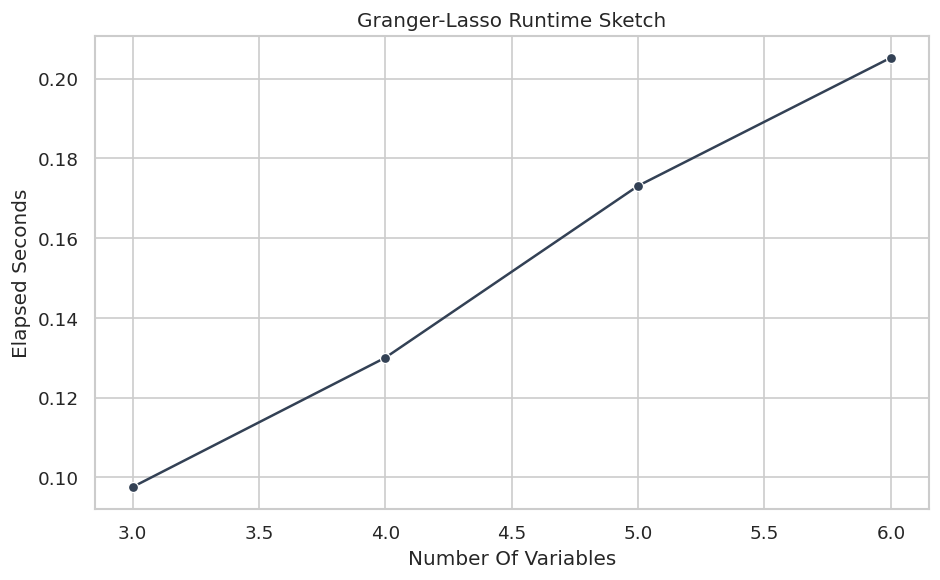

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=runtime_table, x="n_variables", y="elapsed_seconds", marker="o", color="#334155", ax=ax)
ax.set_title("Granger-Lasso Runtime Sketch")
ax.set_xlabel("Number Of Variables")
ax.set_ylabel("Elapsed Seconds")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_granger_runtime_sketch.png", dpi=160, bbox_inches="tight")
plt.show()


The runtime remains small here because the tutorial graph is tiny. The same workflow becomes more expensive when the variable count, maximum lag, or resampling plan grows.


### When to Use a Dedicated Time-Series Discovery Library

`causal-learn` gives us Granger tools and VAR-LiNGAM, which are useful for small and medium teaching workflows. For larger time-series causal discovery, especially conditional-independence search over many lags, a specialized library may be more ergonomic.

The next table summarizes the practical decision boundary.


| need | reasonable_tool | main_warning |
| --- | --- | --- |
| Quick pairwise lag test | causal-learn Granger.granger_test_2d | Pairwise tests omit other variables and can be confounded. |
| Small multivariate lagged graph | causal-learn Granger.granger_lasso | Coefficient threshold and lag length drive the final graph. |
| Same-time plus lagged linear non-Gaussian effects | VAR-LiNGAM | Requires linear non-Gaussian assumptions and careful residual checks. |
| Large lagged conditional-independence workflow | Dedicated time-series discovery package such as Tigramite | Choose tests, lags, and stationarity checks explicitly. |
| Cross-sectional DAG from autocorrelated rows | Usually avoid; first decide the temporal graph target | Naive i.i.d. methods can orient or connect the wrong variables. |


This guidance is deliberately conservative. Time-series discovery is strongest when the question is phrased in temporal terms before any algorithm is run.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Reporting Checklist

A time-series causal discovery report should say exactly what temporal target was estimated. The next table is a reusable checklist for documenting that choice.


| item | what_to_report | why_it_matters |
| --- | --- | --- |
| Sampling unit and cadence | What one row represents and whether the spacing is regular. | Lagged effects only have meaning relative to the measurement interval. |
| Maximum lag | The largest lag tested and why it was chosen. | Too few lags miss delayed effects; too many lags increase false positives. |
| Same-time edge policy | Whether same-time effects are estimated, forbidden, or left unresolved. | Timestamp order alone cannot orient variables measured at the same time. |
| Stationarity checks | Drift, breaks, seasonality, and distribution changes considered before discovery. | Nonstationarity can create spurious lagged dependence. |
| Threshold or significance rule | Coefficient threshold, alpha level, or selection rule used to produce edges. | The graph is often sensitive to this conversion step. |
| Stability analysis | Resampling, rolling windows, or seed checks used to assess graph robustness. | Unstable edges should be treated as hypotheses, not findings. |
| Known omitted variables | Important unobserved drivers or measurement gaps. | Hidden common causes can invalidate Granger and VAR-LiNGAM causal claims. |


This checklist turns the lesson into a reusable analysis template. The estimator output is only one part of the causal claim; the temporal assumptions and reporting choices are equally important.


## Summary

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.
